# Image Search with Milvus

在本笔记中，我们将向您展示如何使用 Milvus 在数据集中搜索相似的图像。我们将使用 ImageNet 数据集的一个子集，然后搜索一张阿富汗猎犬的图像来演示这一过程。

## 数据集准备
首先，我们需要加载数据集并解压以进行后续处理。

In [6]:
import os

os.environ['NLTK_DATA'] = r'F:\Teewon\Milvue\model\nltk_data'

CUSTOM_CACHE = r'F:\Teewon\Milvue\models'
os.environ['HF_HOME'] = CUSTOM_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(CUSTOM_CACHE, 'hub')
os.environ['TORCH_HOME'] = CUSTOM_CACHE

In [7]:
import dotenv

dotenv.load_dotenv('../.env')

True

# 定义特征提取器
接下来，我们需要定义一个特征提取器，该提取器使用 Chinese CLIP 模型从图像中提取嵌入表示。

In [8]:
from PIL import Image
import torch
from transformers import ChineseCLIPProcessor,ChineseCLIPModel
from sklearn.preprocessing import normalize

class FeatureExtractor:
    def __init__(self,model_name="OFA-Sys/chinese-clip-vit-base-patch16"):
        # 加载预训练模型和处理器
        self.model=ChineseCLIPModel.from_pretrained(model_name)
        self.processor=ChineseCLIPProcessor.from_pretrained(model_name)
        self.model.eval()

    def __call__(self, imgpath):
        # 1. 加载图像
        image=Image.open(imgpath).convert('RGB')

        # 2. 预处理图像:processor会自动进行resize, center_crop, 归一化等
        inputs=self.processor(images=image,return_tensors="pt")

        # 3. 提取特征
        with torch.no_grad():
            # 使用 get_image_features 方法直接获取特征
            image_features=self.model.get_image_features(**inputs)

        # 4. L2归一化
        image_features=image_features/image_features.norm(p=2,dim=-1,keepdim=True)

        # 返回归一化后的特征向量 (numpy格式)
        return normalize(image_features.numpy().reshape(1,-1),norm='l2').flatten()

## 创建 Milvus 集合
然后我们需要创建一个 Milvus 集合来存储图像嵌入

In [9]:
from pymilvus import MilvusClient

mc=MilvusClient(uri='http://localhost:19530')
collection_name="image_embeddings"
if mc.has_collection(collection_name):
    mc.drop_collection(collection_name)
mc.create_collection(
    collection_name,
    vector_field_name="vector",
    dimension=512,
    auto_id=True,
    enable_dynamic_fields=True,
    metric_type="COSINE"
)

## 将嵌入向量插入Milvus
我们将使用ChCLIP模型提取每张图像的嵌入向量，并将训练集中的图像插入Milvus。

In [10]:
extractor=FeatureExtractor("OFA-Sys/chinese-clip-vit-base-patch16")

root='./data/reverse_image_search/train'
insert=True
if insert:
    for dirpath,flodername,filenames in os.walk(root):
        for filename in filenames:
            filepath=dirpath+"/"+filename
            image_embedding=extractor(filepath)
            mc.insert(
                collection_name,
                {"vector":image_embedding,"filename":filepath},
            )

'query'

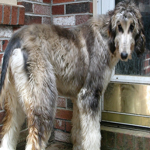

'results'

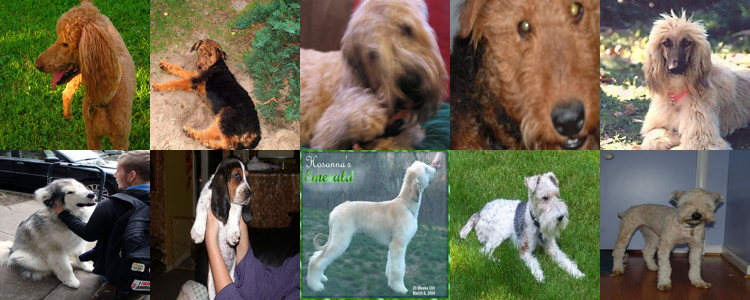

In [12]:
from IPython.display import display

query_image='./data/reverse_image_search/test/Afghan_hound/n02088094_4261.JPEG'

results=mc.search(
    collection_name,
    data=[extractor(query_image)],
    output_fields=["filename"],
    search_params={"metric_type":"COSINE"},
)

images=[]
for result in results:
    for hit in result[:10]:
        filename=hit['entity']['filename']
        img=Image.open(filename)
        img=img.resize((150,150))
        images.append(img)

width=150*5
height=150*2

concatenated_image=Image.new("RGB",(width,height))
for idx, img in enumerate(images):
    x = idx % 5
    y = idx // 5
    concatenated_image.paste(img, (x * 150, y * 150))
display("query")
display(Image.open(query_image).resize((150, 150)))
display("results")
display(concatenated_image)

我们可以看到，大多数图像都与搜索图像属于同一类别，即阿富汗猎犬。这意味着我们找到了与搜索图像相似的图片。

In [13]:
mc.drop_collection(collection_name)